In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [3]:
df = pd.read_csv("../data/raw/loan_data.csv")

In [4]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [5]:
X["loan_to_income"]=(
    X["loan_amnt"] / X["person_income"]
)

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [7]:
print("Numerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_to_income']

Categorical:
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [10]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [12]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [13]:
knn_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            knn_model
        )
    ]
)

In [14]:
knn_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
y_pred = knn_pipeline.predict(X_test)

In [16]:
y_pred[:20]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [17]:
y_prob = knn_pipeline.predict_proba(X_test)[:, 1]

In [18]:
y_prob[:10]

array([0. , 0. , 0. , 0. , 0.8, 0.4, 0. , 0. , 0.2, 0.6])

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [20]:
print("KNN Baseline")
print("-" * 30)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

KNN Baseline
------------------------------
Accuracy : 0.8964
Precision: 0.7973
Recall   : 0.7160
F1 Score : 0.7545
ROC-AUC  : 0.9258


In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7000
           1       0.80      0.72      0.75      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.90      0.89      9000



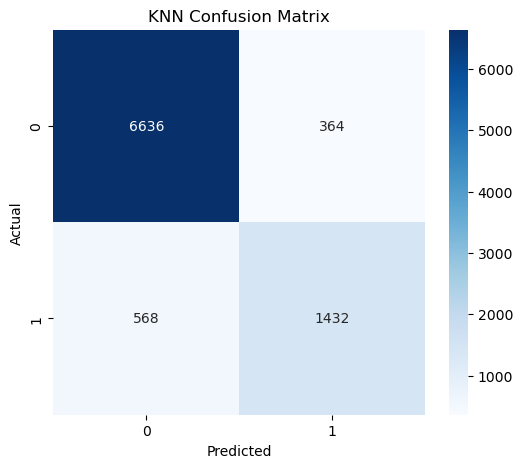

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

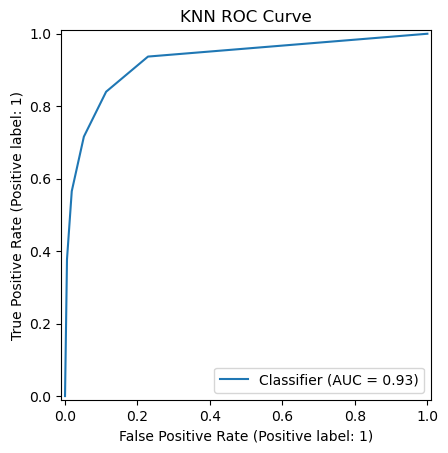

In [31]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("KNN ROC Curve")
plt.show()

In [32]:
k_values = range(1, 21)

results = []

for k in k_values:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=k
                )
            )
        ]
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    results.append({
        "k": k,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        )
    })

In [33]:
knn_results = pd.DataFrame(results)

knn_results

,k,accuracy,precision,recall,f1,roc_auc
0,1,0.877111,0.729231,0.7110,0.720000,0.817786
1,2,0.882111,0.846494,0.5735,0.683756,0.876250
2,3,0.888778,0.769563,0.7130,0.740202,0.903094
3,4,0.890000,0.843071,0.6205,0.714862,0.915762
4,5,0.896444,0.797327,0.7160,0.754478,0.925831
5,6,0.899889,0.856124,0.6605,0.745696,0.934434
6,7,0.902000,0.816535,0.7210,0.765799,0.938106
7,8,0.899333,0.845765,0.6690,0.747069,0.940500
8,9,0.899889,0.813105,0.7135,0.760053,0.943060
9,10,0.901889,0.855054,0.6725,0.752869,0.945513


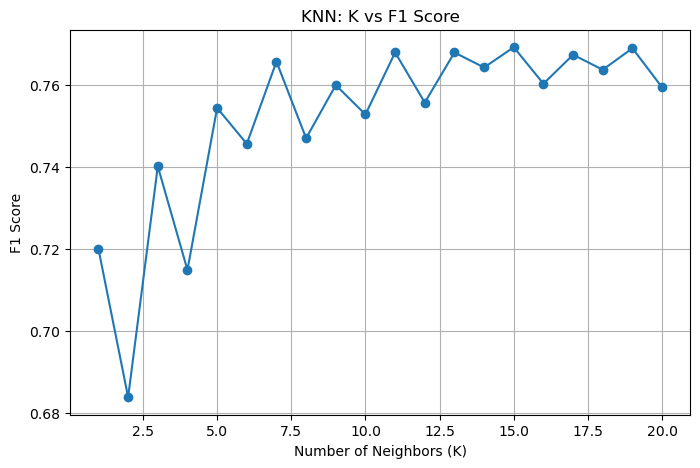

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["k"],
    knn_results["f1"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("F1 Score")
plt.title("KNN: K vs F1 Score")
plt.grid()

plt.show()

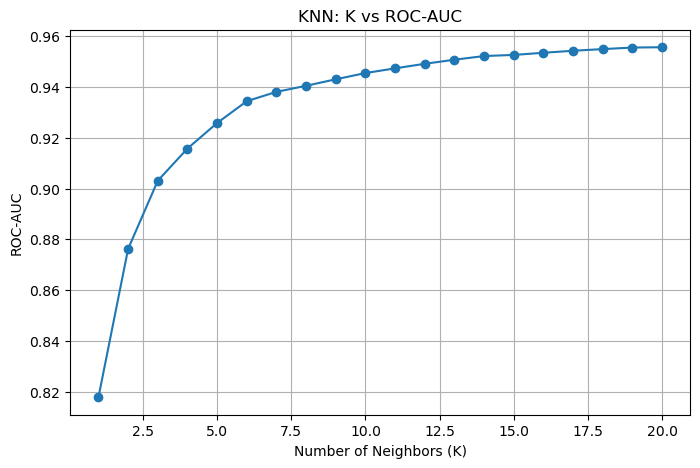

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["k"],
    knn_results["roc_auc"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("ROC-AUC")
plt.title("KNN: K vs ROC-AUC")
plt.grid()

plt.show()

In [36]:
best_k_f1 = knn_results.loc[
    knn_results["f1"].idxmax()
]

best_k_f1

k            15.000000
accuracy      0.905111
precision     0.836663
recall        0.712000
f1            0.769314
roc_auc       0.952658
Name: 14, dtype: float64

In [37]:
best_k_auc = knn_results.loc[
    knn_results["roc_auc"].idxmax()
]

best_k_auc

k            20.000000
accuracy      0.904222
precision     0.859217
recall        0.680500
f1            0.759487
roc_auc       0.955691
Name: 19, dtype: float64

### Comparison between Logistic model and KNN model and Naive Bayes Model


In [23]:
import joblib

logistic_pipeline = joblib.load(
    "../models/logistic_regression_pipeline.joblib"
)

nb_pipeline = joblib.load(
    "../models/gaussian_nb_pipeline.joblib"
)

In [24]:
# Logistic Regression
y_pred_logistic = logistic_pipeline.predict(X_test)
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

# KNN
y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

#Naive Bayes
y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ],

    "F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_nb)
    ]
})

In [26]:
comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.899222,0.787480,0.7485,0.767496,0.956231
1,KNN,0.896444,0.797327,0.7160,0.754478,0.925831
2,Gaussian Naive Bayes,0.736444,0.457418,0.9990,0.627513,0.940514


In [27]:
comparison.set_index("Model").idxmax()

Accuracy      Logistic Regression
Precision                     KNN
Recall       Gaussian Naive Bayes
F1            Logistic Regression
ROC-AUC       Logistic Regression
dtype: object

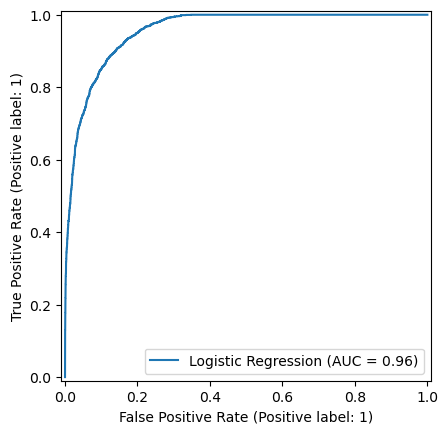

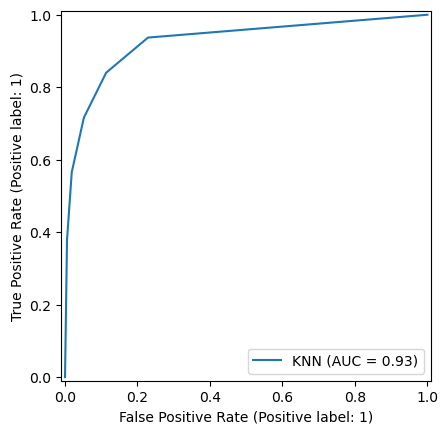

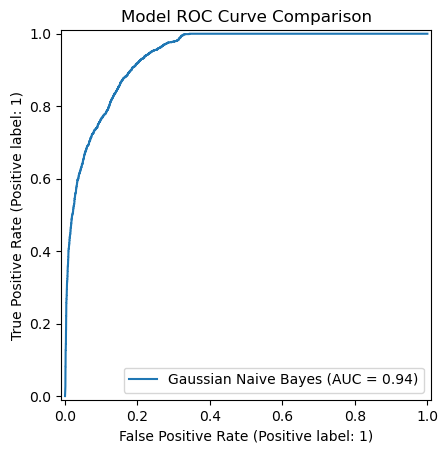

In [28]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_knn,
    name="KNN"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_nb,
    name="Gaussian Naive Bayes"
)

plt.title("Model ROC Curve Comparison")
plt.show()

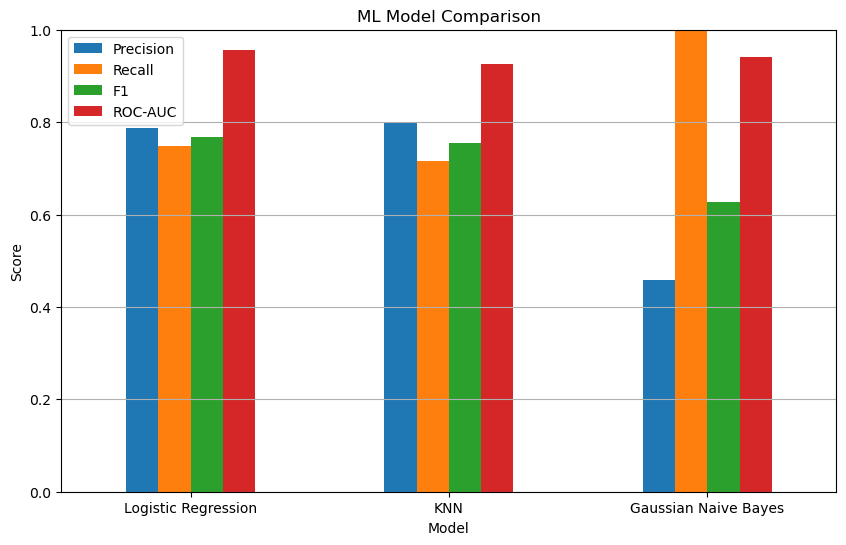

In [29]:
comparison_plot = comparison.set_index("Model")

comparison_plot[
    ["Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("ML Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")

plt.show()